In [2]:
import os
import numpy as np
import pandas as pd
import cv2

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Define the base directory where your folders are located
base_dir = 'Alzheimer_s Dataset'

# List of folder names (these will be the target labels)
folders = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# Prepare lists to hold data
image_paths = []
image_arrays = []
targets = []
image_size = (128, 128)
# Loop through each folder
for folder in folders:
    folder_path = os.path.join(base_dir, folder)
    
    # Loop through each image in the folder
    for img_name in os.listdir(folder_path):
        # Get the full image path
        img_path = os.path.join(folder_path, img_name)
        
        # Read the image using OpenCV
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        # Convert the image from BGR (OpenCV default) to RGB (optional, depending on your use case)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, image_size)
        # Append the path, image array, and target label (folder name)
        image_paths.append(img_path)
        image_arrays.append(img_resized)
        targets.append(folder)

# Create a DataFrame
df = pd.DataFrame({
    'image_path': image_paths,
    'image_array': image_arrays,
    'target': targets
})

# Display the DataFrame
df.head()


,image_path,image_array,target
0,Alzheimer_s Dataset\MildDemented\26 (19).jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",MildDemented
1,Alzheimer_s Dataset\MildDemented\26 (20).jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",MildDemented
2,Alzheimer_s Dataset\MildDemented\26 (21).jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",MildDemented
3,Alzheimer_s Dataset\MildDemented\26 (22).jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",MildDemented
4,Alzheimer_s Dataset\MildDemented\26 (23).jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",MildDemented


In [3]:
df.shape

(6400, 3)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6400 entries, 0 to 6399
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   image_path   6400 non-null   object
 1   image_array  6400 non-null   object
 2   target       6400 non-null   object
dtypes: object(3)
memory usage: 150.1+ KB


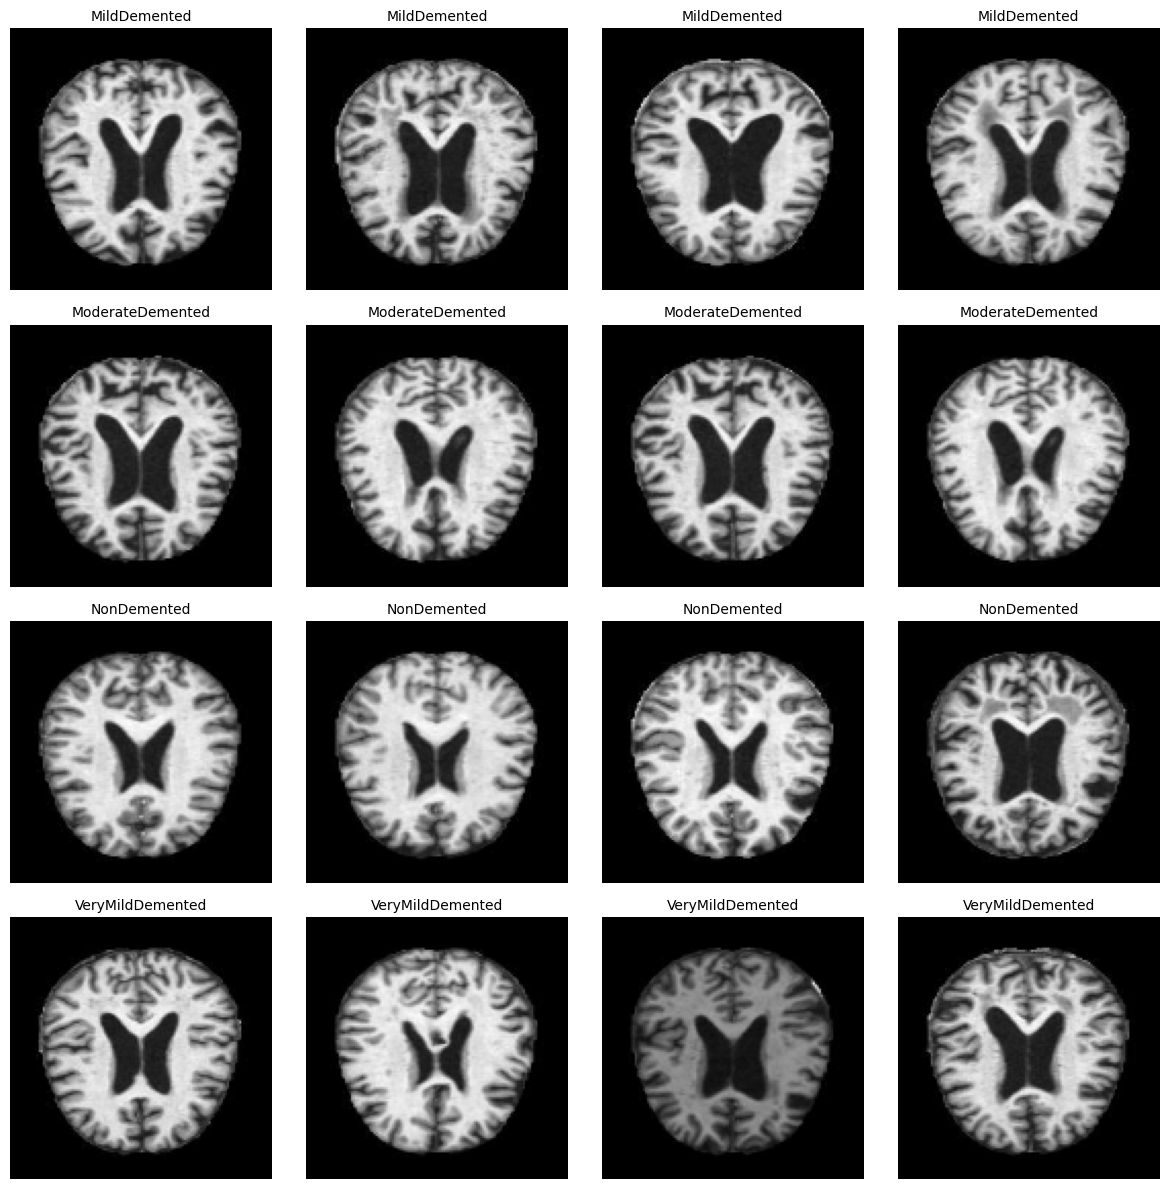

In [5]:
import matplotlib.pyplot as plt

# Number of images to display for each target
num_images = 4

# Set up the plot grid
fig, axs = plt.subplots(len(folders), num_images, figsize=(12, 12))

# Loop through each target (folder name)
for i, folder in enumerate(folders):
    # Get the first 4 images for the current target label
    target_images = df[df['target'] == folder]['image_array'].head(num_images)
    
    # Plot 4 images in the row corresponding to the current target
    for j, img_array in enumerate(target_images):
        # Display the image
        axs[i, j].imshow(img_array)
        axs[i, j].axis('off')  # Hide the axis for a cleaner display
        axs[i, j].set_title(f'{folder}', fontsize=10)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


In [6]:
dict_c = {'MildDemented':0, 'ModerateDemented':1, 'NonDemented':2, 'VeryMildDemented':3}
df['target'] = df['target'].map(dict_c)
df.tail()

,image_path,image_array,target
6395,Alzheimer_s Dataset\VeryMildDemented\verymildD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3
6396,Alzheimer_s Dataset\VeryMildDemented\verymildD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3
6397,Alzheimer_s Dataset\VeryMildDemented\verymildD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3
6398,Alzheimer_s Dataset\VeryMildDemented\verymildD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3
6399,Alzheimer_s Dataset\VeryMildDemented\verymildD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3


In [7]:
df['image_array'][68].shape

(128, 128, 3)

In [24]:
df['target'].value_counts()


target
NonDemented         3200
VeryMildDemented    2240
MildDemented         896
ModerateDemented      64
Name: count, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split
import numpy as np

# Assuming df has already been updated with numeric targets
# Flatten the image arrays and convert them into a numpy array
X = np.array([img.flatten() for img in df['image_array']])  # Flatten each image
y = df['target'].values  # Target labels

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing data
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (5120, 49152)
X_test shape: (1280, 49152)
y_train shape: (5120,)
y_test shape: (1280,)


In [9]:
X_train = X_train/255.0
X_test = X_test/255.0

In [10]:
X[10].shape

(49152,)

In [11]:
df['target'].value_counts()

target
2    3200
3    2240
0     896
1      64
Name: count, dtype: int64

In [12]:
## KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

# Initialize the KNN model
knn = KNeighborsClassifier(n_neighbors=3)  # You can adjust the number of neighbors

# Fit the model to the training data
knn.fit(X_train, y_train)

# Make predictions on the test data
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

# Evaluate the model
print(f"Accucary of model:{accuracy}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accucary of model:0.984375
Confusion Matrix:
[[189   0   9   3]
 [  0   6   0   0]
 [  2   0 639   2]
 [  0   0   4 426]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96       201
           1       1.00      1.00      1.00         6
           2       0.98      0.99      0.99       643
           3       0.99      0.99      0.99       430

    accuracy                           0.98      1280
   macro avg       0.99      0.98      0.99      1280
weighted avg       0.98      0.98      0.98      1280



In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the Decision Tree model
dtree = DecisionTreeClassifier(random_state=42,max_depth = 10)  # You can adjust parameters as needed

# Fit the model to the training data
dtree.fit(X_train, y_train)

# Make predictions on the test data
y_pred_dtree = dtree.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_dtree)

print(f"Accuracy: {accuracy:.2f}")


Accuracy: 0.68


In [14]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # You can adjust parameters as needed

# Fit the model to the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy_rf:.2f}")
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.93
Confusion Matrix:
[[155   0  16  30]
 [  0   5   0   1]
 [  0   0 636   7]
 [  0   0  37 393]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.77      0.87       201
           1       1.00      0.83      0.91         6
           2       0.92      0.99      0.95       643
           3       0.91      0.91      0.91       430

    accuracy                           0.93      1280
   macro avg       0.96      0.88      0.91      1280
weighted avg       0.93      0.93      0.93      1280



In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the Logistic Regression model
logreg = LogisticRegression(max_iter=1000, random_state=42)  # You can adjust the max_iter as needed

# Fit the model to the training data
logreg.fit(X_train, y_train)

# Make predictions on the test data
y_pred = logreg.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Evaluate the model
print(f"Accuracy of Logistic Regression model: {accuracy}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy of Logistic Regression model: 0.971875
Confusion Matrix:
[[191   0   7   3]
 [  0   6   0   0]
 [  0   0 631  12]
 [  4   0  10 416]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       201
           1       1.00      1.00      1.00         6
           2       0.97      0.98      0.98       643
           3       0.97      0.97      0.97       430

    accuracy                           0.97      1280
   macro avg       0.98      0.97      0.98      1280
weighted avg       0.97      0.97      0.97      1280



In [16]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Initialize the AdaBoost model (using the default base estimator, which is DecisionTreeClassifier)
ada_model = AdaBoostClassifier(n_estimators=50, random_state=42)

# Fit the model to the training data
ada_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_ada = ada_model.predict(X_test)

# Calculate accuracy
accuracy_ada = accuracy_score(y_test, y_pred_ada)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada))
print(f"Accuracy: {accuracy_ada:.2f}")


Confusion Matrix:
[[ 33   0  66 102]
 [  1   3   1   1]
 [ 21   0 490 132]
 [ 26   0 217 187]]

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.16      0.23       201
           1       1.00      0.50      0.67         6
           2       0.63      0.76      0.69       643
           3       0.44      0.43      0.44       430

    accuracy                           0.56      1280
   macro avg       0.62      0.47      0.51      1280
weighted avg       0.54      0.56      0.53      1280

Accuracy: 0.56


In [17]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the SVM model (you can also specify different kernels like 'linear', 'rbf', etc.)
svm_model = SVC(kernel='linear')  # You can change 'linear' to 'rbf', 'poly', etc.

# Fit the model to the training data
svm_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of model: {accuracy * 100:.2f}%")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy of model: 99.06%
Confusion Matrix:
[[195   0   4   2]
 [  0   6   0   0]
 [  0   0 640   3]
 [  1   0   2 427]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       201
           1       1.00      1.00      1.00         6
           2       0.99      1.00      0.99       643
           3       0.99      0.99      0.99       430

    accuracy                           0.99      1280
   macro avg       0.99      0.99      0.99      1280
weighted avg       0.99      0.99      0.99      1280



# UnderSampling

In [18]:
# Get the count of each class in the 'target' column
class_counts = df['target'].value_counts()

# Store the counts of each class in variables
class_0 = class_counts.get(0, 0)
class_1 = class_counts.get(1, 0)
class_2 = class_counts.get(2, 0)
class_3 = class_counts.get(3, 0)

# Print the class counts
print(f"Class 0 count: {class_0}")
print(f"Class 1 count: {class_1}")
print(f"Class 2 count: {class_2}")
print(f"Class 3 count: {class_3}")


Class 0 count: 896
Class 1 count: 64
Class 2 count: 3200
Class 3 count: 2240


In [19]:
# Divide by class
df_class_0 = df[df['target'] == 0]
df_class_1 = df[df['target'] == 1]
df_class_2 = df[df['target'] == 2]
df_class_3 = df[df['target'] == 3]

# Print the shape of each class
print(f"Class 0 shape: {df_class_0.shape}")
print(f"Class 1 shape: {df_class_1.shape}")
print(f"Class 2 shape: {df_class_2.shape}")
print(f"Class 3 shape: {df_class_3.shape}")




Class 0 shape: (896, 3)
Class 1 shape: (64, 3)
Class 2 shape: (3200, 3)
Class 3 shape: (2240, 3)


In [20]:
# Get the counts of each class
count_class_0 = df_class_0.shape[0]  # 896
count_class_1 = df_class_1.shape[0]  # 64
count_class_2 = df_class_2.shape[0]  # 3200
count_class_3 = df_class_3.shape[0]  # 2240

# Find the class with the minimum count (which is class 1 with 64 instances)
min_class_count = count_class_1  # Since class 1 has the fewest instances

# Undersample the other classes (0, 2, and 3) to match the size of class 1
df_class_0_under = df_class_0.sample(min_class_count)
df_class_2_under = df_class_2.sample(min_class_count)
df_class_3_under = df_class_3.sample(min_class_count)

# Concatenate the undersampled classes with class 1
df_balanced = pd.concat([df_class_0_under, df_class_1, df_class_2_under, df_class_3_under], axis=0)

# Print the class distribution after undersampling
print('Class distribution after random undersampling:')
print(df_balanced['target'].value_counts())
df_balanced.head()

Class distribution after random undersampling:
target
0    64
1    64
2    64
3    64
Name: count, dtype: int64


,image_path,image_array,target
197,Alzheimer_s Dataset\MildDemented\mildDem114.jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0
892,Alzheimer_s Dataset\MildDemented\mildDem96.jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0
178,Alzheimer_s Dataset\MildDemented\32.jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0
844,Alzheimer_s Dataset\MildDemented\mildDem698.jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0
761,Alzheimer_s Dataset\MildDemented\mildDem622.jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0


In [21]:
# Assuming df has already been updated with numeric targets
# Flatten the image arrays and convert them into a numpy array
X = np.array([img.flatten() for img in df_balanced['image_array']])  # Flatten each image
y = df_balanced['target'].values  # Target labels

# Split the data into training and testing sets (80% training, 20% testing)
X_train_undersampling, X_test_undersampling, y_train_undersampling, y_test_undersampling = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing data
print(f"X_train shape: {X_train_undersampling.shape}")
print(f"X_test shape: {X_test_undersampling.shape}")
print(f"y_train shape: {y_train_undersampling.shape}")
print(f"y_test shape: {y_test_undersampling.shape}")

X_train shape: (204, 49152)
X_test shape: (52, 49152)
y_train shape: (204,)
y_test shape: (52,)


### Machine Learning Algorithms 

In [22]:
# K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the model
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_undersampling, y_train_undersampling)

# Make predictions
y_pred_knn = knn.predict(X_test_undersampling)

# Evaluate the model
# Accuracy
print("K-Nearest Neighbors (KNN) Accuracy:", accuracy_score(y_test_undersampling, y_pred_knn))

# Confusion Matrix
print("K-Nearest Neighbors (KNN) Confusion Matrix:\n", confusion_matrix(y_test_undersampling, y_pred_knn))

# Classification Report
print("K-Nearest Neighbors (KNN) Classification Report:\n", classification_report(y_test_undersampling, y_pred_knn))


K-Nearest Neighbors (KNN) Accuracy: 0.5961538461538461
K-Nearest Neighbors (KNN) Confusion Matrix:
 [[ 8  3  2  0]
 [ 0 11  0  0]
 [ 0  1  9  3]
 [ 6  3  3  3]]
K-Nearest Neighbors (KNN) Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.62      0.59        13
           1       0.61      1.00      0.76        11
           2       0.64      0.69      0.67        13
           3       0.50      0.20      0.29        15

    accuracy                           0.60        52
   macro avg       0.58      0.63      0.58        52
weighted avg       0.58      0.60      0.56        52



In [23]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Initialize the model
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(X_train_undersampling, y_train_undersampling)

# Make predictions
y_pred_dt = dt.predict(X_test_undersampling)

# Evaluate the model
# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test_undersampling, y_pred_dt))

# Confusion Matrix
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test_undersampling, y_pred_dt))

# Classification Report
print("Decision Tree Classification Report:\n", classification_report(y_test_undersampling, y_pred_dt))


Decision Tree Accuracy: 0.4807692307692308
Decision Tree Confusion Matrix:
 [[4 4 2 3]
 [2 8 0 1]
 [1 0 9 3]
 [7 1 3 4]]
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.31      0.30        13
           1       0.62      0.73      0.67        11
           2       0.64      0.69      0.67        13
           3       0.36      0.27      0.31        15

    accuracy                           0.48        52
   macro avg       0.48      0.50      0.48        52
weighted avg       0.47      0.48      0.47        52



In [24]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Initialize the model
lr = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
lr.fit(X_train_undersampling, y_train_undersampling)

# Make predictions
y_pred_lr = lr.predict(X_test_undersampling)

# Evaluate the model
# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test_undersampling, y_pred_lr))

# Confusion Matrix
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test_undersampling, y_pred_lr))

# Classification Report
print("Logistic Regression Classification Report:\n", classification_report(y_test_undersampling, y_pred_lr))


Logistic Regression Accuracy: 0.6730769230769231
Logistic Regression Confusion Matrix:
 [[12  0  0  1]
 [ 0 11  0  0]
 [ 1  0  8  4]
 [ 7  0  4  4]]
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.92      0.73        13
           1       1.00      1.00      1.00        11
           2       0.67      0.62      0.64        13
           3       0.44      0.27      0.33        15

    accuracy                           0.67        52
   macro avg       0.68      0.70      0.68        52
weighted avg       0.66      0.67      0.65        52



In [25]:
# Support Vector Machine (SVM)
from sklearn.svm import SVC

# Initialize the model
svm = SVC(random_state=42)

# Train the model
svm.fit(X_train_undersampling, y_train_undersampling)

# Make predictions
y_pred_svm = svm.predict(X_test_undersampling)

# Evaluate the model
# Accuracy
print("Support Vector Machine (SVM) Accuracy:", accuracy_score(y_test_undersampling, y_pred_svm))

# Confusion Matrix
print("Support Vector Machine (SVM) Confusion Matrix:\n", confusion_matrix(y_test_undersampling, y_pred_svm))

# Classification Report
print("Support Vector Machine (SVM) Classification Report:\n", classification_report(y_test_undersampling, y_pred_svm))


Support Vector Machine (SVM) Accuracy: 0.6153846153846154
Support Vector Machine (SVM) Confusion Matrix:
 [[ 9  2  0  2]
 [ 0 10  1  0]
 [ 3  0  6  4]
 [ 6  0  2  7]]
Support Vector Machine (SVM) Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.69      0.58        13
           1       0.83      0.91      0.87        11
           2       0.67      0.46      0.55        13
           3       0.54      0.47      0.50        15

    accuracy                           0.62        52
   macro avg       0.63      0.63      0.62        52
weighted avg       0.62      0.62      0.61        52



In [26]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Initialize the model
nb = GaussianNB()

# Train the model
nb.fit(X_train_undersampling, y_train_undersampling)

# Make predictions
y_pred_nb = nb.predict(X_test_undersampling)

# Evaluate the model
# Accuracy
print("Naive Bayes Accuracy:", accuracy_score(y_test_undersampling, y_pred_nb))

# Confusion Matrix
print("Naive Bayes Confusion Matrix:\n", confusion_matrix(y_test_undersampling, y_pred_nb))

# Classification Report
print("Naive Bayes Classification Report:\n", classification_report(y_test_undersampling, y_pred_nb))


Naive Bayes Accuracy: 0.4807692307692308
Naive Bayes Confusion Matrix:
 [[5 0 4 4]
 [2 7 2 0]
 [2 0 7 4]
 [4 1 4 6]]
Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.38      0.38        13
           1       0.88      0.64      0.74        11
           2       0.41      0.54      0.47        13
           3       0.43      0.40      0.41        15

    accuracy                           0.48        52
   macro avg       0.52      0.49      0.50        52
weighted avg       0.51      0.48      0.49        52



### Ensemble Learning Algorithms

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf.fit(X_train_undersampling, y_train_undersampling)

# Predict on test data
y_pred_rf = rf.predict(X_test_undersampling)

# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test_undersampling, y_pred_rf))

# Confusion Matrix
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test_undersampling, y_pred_rf))

# Classification Metrics
print("Random Forest Classification Report:\n", classification_report(y_test_undersampling, y_pred_rf))


Random Forest Accuracy: 0.6923076923076923
Random Forest Confusion Matrix:
 [[12  0  0  1]
 [ 0 11  0  0]
 [ 2  0 10  1]
 [ 7  0  5  3]]
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.92      0.71        13
           1       1.00      1.00      1.00        11
           2       0.67      0.77      0.71        13
           3       0.60      0.20      0.30        15

    accuracy                           0.69        52
   macro avg       0.71      0.72      0.68        52
weighted avg       0.69      0.69      0.65        52



In [28]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)

# Train the model
gb.fit(X_train_undersampling, y_train_undersampling)

# Predict on test data
y_pred_gb = gb.predict(X_test_undersampling)

# Accuracy
print("Gradient Boosting Accuracy:", accuracy_score(y_test_undersampling, y_pred_gb))

# Confusion Matrix
print("Gradient Boosting Confusion Matrix:\n", confusion_matrix(y_test_undersampling, y_pred_gb))

# Classification Metrics
print("Gradient Boosting Classification Report:\n", classification_report(y_test_undersampling, y_pred_gb))


Gradient Boosting Accuracy: 0.5576923076923077
Gradient Boosting Confusion Matrix:
 [[ 9  0  1  3]
 [ 0 10  1  0]
 [ 1  0  7  5]
 [ 6  0  6  3]]
Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.69      0.62        13
           1       1.00      0.91      0.95        11
           2       0.47      0.54      0.50        13
           3       0.27      0.20      0.23        15

    accuracy                           0.56        52
   macro avg       0.58      0.58      0.58        52
weighted avg       0.55      0.56      0.55        52



In [29]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize AdaBoost
ab = AdaBoostClassifier(n_estimators=50, random_state=42)

# Train the model
ab.fit(X_train_undersampling, y_train_undersampling)

# Predict on test data
y_pred_ab = ab.predict(X_test_undersampling)

# Accuracy
print("AdaBoost Accuracy:", accuracy_score(y_test_undersampling, y_pred_ab))

# Confusion Matrix
print("AdaBoost Confusion Matrix:\n", confusion_matrix(y_test_undersampling, y_pred_ab))

# Classification Metrics
print("AdaBoost Classification Report:\n", classification_report(y_test_undersampling, y_pred_ab))


AdaBoost Accuracy: 0.36538461538461536
AdaBoost Confusion Matrix:
 [[ 7  0  1  5]
 [ 6  3  0  2]
 [ 1  0  1 11]
 [ 2  0  5  8]]
AdaBoost Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.54      0.48        13
           1       1.00      0.27      0.43        11
           2       0.14      0.08      0.10        13
           3       0.31      0.53      0.39        15

    accuracy                           0.37        52
   macro avg       0.47      0.36      0.35        52
weighted avg       0.45      0.37      0.35        52



# OverSampling

In [30]:
# Get the count of the maximum class (class with the most instances)
max_class_count = max(count_class_0, count_class_1, count_class_2, count_class_3)

# Oversample all classes to the max class count
df_class_0_over = df_class_0.sample(max_class_count, replace=True)
df_class_1_over = df_class_1.sample(max_class_count, replace=True)
df_class_2_over = df_class_2.sample(max_class_count, replace=True)
df_class_3_over = df_class_3.sample(max_class_count, replace=True)

# Concatenate all the oversampled DataFrames
df_test_over = pd.concat([df_class_0_over, df_class_1_over, df_class_2_over, df_class_3_over], axis=0)

# Print the value counts of the target class in the oversampled DataFrame
print('Random over-sampling:')
print(df_test_over['target'].value_counts())  # 'target' is the column holding your class labels


Random over-sampling:
target
0    3200
1    3200
2    3200
3    3200
Name: count, dtype: int64


In [31]:
# Assuming df has already been updated with numeric targets
# Flatten the image arrays and convert them into a numpy array
X = np.array([img.flatten() for img in df_test_over['image_array']])  # Flatten each image
y = df_test_over['target'].values  # Target labels

# Split the data into training and testing sets (80% training, 20% testing)
X_train_oversampling, X_test_oversampling, y_train_oversampling, y_test_oversampling = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing data
print(f"X_train shape: {X_train_oversampling.shape}")
print(f"X_test shape: {X_test_oversampling.shape}")
print(f"y_train shape: {y_train_oversampling.shape}")
print(f"y_test shape: {y_test_oversampling.shape}")

X_train shape: (10240, 49152)
X_test shape: (2560, 49152)
y_train shape: (10240,)
y_test shape: (2560,)


In [32]:
# K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)

# Fit the model on the oversampled training data
knn.fit(X_train_oversampling, y_train_oversampling)

# Predict on the test set
y_pred_knn = knn.predict(X_test_oversampling)

# Calculate accuracy
accuracy_knn = accuracy_score(y_test_oversampling, y_pred_knn)
print(f"KNN Accuracy: {accuracy_knn}")

# Confusion matrix
conf_matrix_knn = confusion_matrix(y_test_oversampling, y_pred_knn)
print(f"KNN Confusion Matrix:\n{conf_matrix_knn}")

# Classification report
class_report_knn = classification_report(y_test_oversampling, y_pred_knn)
print(f"KNN Classification Report:\n{class_report_knn}")


KNN Accuracy: 0.99375
KNN Confusion Matrix:
[[665   0   0   0]
 [  0 625   0   0]
 [  3   0 623   9]
 [  0   0   4 631]]
KNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       665
           1       1.00      1.00      1.00       625
           2       0.99      0.98      0.99       635
           3       0.99      0.99      0.99       635

    accuracy                           0.99      2560
   macro avg       0.99      0.99      0.99      2560
weighted avg       0.99      0.99      0.99      2560



In [33]:
# Decision Trees
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree classifier
dt = DecisionTreeClassifier(random_state=42)

# Fit the model on the oversampled training data
dt.fit(X_train_oversampling, y_train_oversampling)

# Predict on the test set
y_pred_dt = dt.predict(X_test_oversampling)

# Calculate accuracy
accuracy_dt = accuracy_score(y_test_oversampling, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt}")

# Confusion matrix
conf_matrix_dt = confusion_matrix(y_test_oversampling, y_pred_dt)
print(f"Decision Tree Confusion Matrix:\n{conf_matrix_dt}")

# Classification report
class_report_dt = classification_report(y_test_oversampling, y_pred_dt)
print(f"Decision Tree Classification Report:\n{class_report_dt}")


Decision Tree Accuracy: 0.9421875
Decision Tree Confusion Matrix:
[[655   0   6   4]
 [  0 625   0   0]
 [ 17   1 556  61]
 [ 14   0  45 576]]
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       665
           1       1.00      1.00      1.00       625
           2       0.92      0.88      0.90       635
           3       0.90      0.91      0.90       635

    accuracy                           0.94      2560
   macro avg       0.94      0.94      0.94      2560
weighted avg       0.94      0.94      0.94      2560



In [34]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression classifier
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Fit the model on the oversampled training data
log_reg.fit(X_train_oversampling, y_train_oversampling)

# Predict on the test set
y_pred_log_reg = log_reg.predict(X_test_oversampling)

# Calculate accuracy
accuracy_log_reg = accuracy_score(y_test_oversampling, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {accuracy_log_reg}")

# Confusion matrix
conf_matrix_log_reg = confusion_matrix(y_test_oversampling, y_pred_log_reg)
print(f"Logistic Regression Confusion Matrix:\n{conf_matrix_log_reg}")

# Classification report
class_report_log_reg = classification_report(y_test_oversampling, y_pred_log_reg)
print(f"Logistic Regression Classification Report:\n{class_report_log_reg}")


Logistic Regression Accuracy: 0.9890625
Logistic Regression Confusion Matrix:
[[665   0   0   0]
 [  0 625   0   0]
 [  2   0 615  18]
 [  2   0   6 627]]
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       665
           1       1.00      1.00      1.00       625
           2       0.99      0.97      0.98       635
           3       0.97      0.99      0.98       635

    accuracy                           0.99      2560
   macro avg       0.99      0.99      0.99      2560
weighted avg       0.99      0.99      0.99      2560



In [35]:
# Support Vector Machine (SVM)
from sklearn.svm import SVC

# Initialize SVM classifier
svm = SVC(random_state=42)

# Fit the model on the oversampled training data
svm.fit(X_train_oversampling, y_train_oversampling)

# Predict on the test set
y_pred_svm = svm.predict(X_test_oversampling)

# Calculate accuracy
accuracy_svm = accuracy_score(y_test_oversampling, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm}")

# Confusion matrix
conf_matrix_svm = confusion_matrix(y_test_oversampling, y_pred_svm)
print(f"SVM Confusion Matrix:\n{conf_matrix_svm}")

# Classification report
class_report_svm = classification_report(y_test_oversampling, y_pred_svm)
print(f"SVM Classification Report:\n{class_report_svm}")


SVM Accuracy: 0.91875
SVM Confusion Matrix:
[[662   0   1   2]
 [  0 625   0   0]
 [ 36   0 523  76]
 [ 39   0  54 542]]
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.94       665
           1       1.00      1.00      1.00       625
           2       0.90      0.82      0.86       635
           3       0.87      0.85      0.86       635

    accuracy                           0.92      2560
   macro avg       0.92      0.92      0.92      2560
weighted avg       0.92      0.92      0.92      2560



In [36]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Initialize Naive Bayes classifier
nb = GaussianNB()

# Fit the model on the oversampled training data
nb.fit(X_train_oversampling, y_train_oversampling)

# Predict on the test set
y_pred_nb = nb.predict(X_test_oversampling)

# Calculate accuracy
accuracy_nb = accuracy_score(y_test_oversampling, y_pred_nb)
print(f"Naive Bayes Accuracy: {accuracy_nb}")

# Confusion matrix
conf_matrix_nb = confusion_matrix(y_test_oversampling, y_pred_nb)
print(f"Naive Bayes Confusion Matrix:\n{conf_matrix_nb}")

# Classification report
class_report_nb = classification_report(y_test_oversampling, y_pred_nb)
print(f"Naive Bayes Classification Report:\n{class_report_nb}")


Naive Bayes Accuracy: 0.63203125
Naive Bayes Confusion Matrix:
[[452   5  91 117]
 [ 30 563  14  18]
 [109   0 437  89]
 [220   4 245 166]]
Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.68      0.61       665
           1       0.98      0.90      0.94       625
           2       0.56      0.69      0.61       635
           3       0.43      0.26      0.32       635

    accuracy                           0.63      2560
   macro avg       0.63      0.63      0.62      2560
weighted avg       0.63      0.63      0.62      2560



### Ensemble Learning Implementation

In [37]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest classifier
rf = RandomForestClassifier(random_state=42)

# Fit the model on the oversampled training data
rf.fit(X_train_oversampling, y_train_oversampling)

# Predict on the test set
y_pred_rf = rf.predict(X_test_oversampling)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test_oversampling, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf}")

# Confusion matrix
conf_matrix_rf = confusion_matrix(y_test_oversampling, y_pred_rf)
print(f"Random Forest Confusion Matrix:\n{conf_matrix_rf}")

# Classification report
class_report_rf = classification_report(y_test_oversampling, y_pred_rf)
print(f"Random Forest Classification Report:\n{class_report_rf}")


Random Forest Accuracy: 0.98984375
Random Forest Confusion Matrix:
[[665   0   0   0]
 [  0 625   0   0]
 [  2   0 617  16]
 [  0   0   8 627]]
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       665
           1       1.00      1.00      1.00       625
           2       0.99      0.97      0.98       635
           3       0.98      0.99      0.98       635

    accuracy                           0.99      2560
   macro avg       0.99      0.99      0.99      2560
weighted avg       0.99      0.99      0.99      2560



In [39]:
# AdaBoost Classifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Initialize AdaBoost classifier
ada = AdaBoostClassifier(n_estimators=50, random_state=42)

# Fit the model on the oversampled training data
ada.fit(X_train_oversampling, y_train_oversampling)

# Predict on the test set
y_pred_ada = ada.predict(X_test_oversampling)

# Calculate accuracy
accuracy_ada = accuracy_score(y_test_oversampling, y_pred_ada)
print(f"AdaBoost Accuracy: {accuracy_ada}")

# Confusion matrix
conf_matrix_ada = confusion_matrix(y_test_oversampling, y_pred_ada)
print(f"AdaBoost Confusion Matrix:\n{conf_matrix_ada}")

# Classification report
class_report_ada = classification_report(y_test_oversampling, y_pred_ada)
print(f"AdaBoost Classification Report:\n{class_report_ada}")


AdaBoost Accuracy: 0.586328125
AdaBoost Confusion Matrix:
[[301   0 213 151]
 [ 53 572   0   0]
 [103   0 412 120]
 [154   0 265 216]]
AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.45      0.47       665
           1       1.00      0.92      0.96       625
           2       0.46      0.65      0.54       635
           3       0.44      0.34      0.39       635

    accuracy                           0.59      2560
   macro avg       0.60      0.59      0.59      2560
weighted avg       0.60      0.59      0.59      2560



# SMOTE

In [12]:
# Initialize SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)

# Apply SMOTE to the dataset
X_sm, y_sm = smote.fit_resample(X, y)

# Convert the resampled target to a Pandas Series to use value_counts()
y_sm_series = pd.Series(y_sm)

# Check the distribution of classes after SMOTE
print("Class distribution after SMOTE:")
print(y_sm_series.value_counts())

Class distribution after SMOTE:
MildDemented        3200
ModerateDemented    3200
NonDemented         3200
VeryMildDemented    3200
Name: count, dtype: int64


In [13]:
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    X_sm, y_sm, test_size=0.2, random_state=42, stratify=y_sm
)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred_lr = lr_model.predict(X_test_smote)

# Evaluate the model
print("Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test_smote, y_pred_lr):.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_smote, y_pred_lr))
print("Classification Report:")
print(classification_report(y_test_smote, y_pred_lr))


Logistic Regression
Accuracy: 0.91
Confusion Matrix:
[[533  33   4  70]
 [  6 628   0   6]
 [  2   0 621  17]
 [ 61  15  28 536]]
Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.89      0.83      0.86       640
ModerateDemented       0.93      0.98      0.95       640
     NonDemented       0.95      0.97      0.96       640
VeryMildDemented       0.85      0.84      0.84       640

        accuracy                           0.91      2560
       macro avg       0.90      0.91      0.90      2560
    weighted avg       0.90      0.91      0.90      2560



In [16]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred_dt = dt_model.predict(X_test_smote)

# Evaluate the model
print("Decision Tree")
print(f"Accuracy: {accuracy_score(y_test_smote, y_pred_dt):.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_smote, y_pred_dt))
print("Classification Report:")
print(classification_report(y_test_smote, y_pred_dt))


Decision Tree
Accuracy: 0.73
Confusion Matrix:
[[418  33  36 153]
 [ 21 594   3  22]
 [ 51   7 487  95]
 [130  19 117 374]]
Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.67      0.65      0.66       640
ModerateDemented       0.91      0.93      0.92       640
     NonDemented       0.76      0.76      0.76       640
VeryMildDemented       0.58      0.58      0.58       640

        accuracy                           0.73      2560
       macro avg       0.73      0.73      0.73      2560
    weighted avg       0.73      0.73      0.73      2560



In [17]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred_knn = knn_model.predict(X_test_smote)

# Evaluate the model
print("K-Nearest Neighbors")
print(f"Accuracy: {accuracy_score(y_test_smote, y_pred_knn):.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_smote, y_pred_knn))
print("Classification Report:")
print(classification_report(y_test_smote, y_pred_knn))


K-Nearest Neighbors
Accuracy: 0.89
Confusion Matrix:
[[463   0 154  23]
 [  0 640   0   0]
 [  3   0 631   6]
 [  7   1  98 534]]
Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.98      0.72      0.83       640
ModerateDemented       1.00      1.00      1.00       640
     NonDemented       0.71      0.99      0.83       640
VeryMildDemented       0.95      0.83      0.89       640

        accuracy                           0.89      2560
       macro avg       0.91      0.89      0.89      2560
    weighted avg       0.91      0.89      0.89      2560



In [18]:
from sklearn.naive_bayes import GaussianNB

# Initialize and train the Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred_nb = nb_model.predict(X_test_smote)

# Evaluate the model
print("Naive Bayes")
print(f"Accuracy: {accuracy_score(y_test_smote, y_pred_nb):.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_smote, y_pred_nb))
print("Classification Report:")
print(classification_report(y_test_smote, y_pred_nb))


Naive Bayes
Accuracy: 0.51
Confusion Matrix:
[[121 261 179  79]
 [  0 520  28  92]
 [  0   0 638   2]
 [ 44 102 460  34]]
Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.73      0.19      0.30       640
ModerateDemented       0.59      0.81      0.68       640
     NonDemented       0.49      1.00      0.66       640
VeryMildDemented       0.16      0.05      0.08       640

        accuracy                           0.51      2560
       macro avg       0.49      0.51      0.43      2560
    weighted avg       0.49      0.51      0.43      2560



In [19]:
from sklearn.svm import SVC

# Initialize and train the SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred_svm = svm_model.predict(X_test_smote)

# Evaluate the model
print("Support Vector Machine")
print(f"Accuracy: {accuracy_score(y_test_smote, y_pred_svm):.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_smote, y_pred_svm))
print("Classification Report:")
print(classification_report(y_test_smote, y_pred_svm))


Support Vector Machine
Accuracy: 0.92
Confusion Matrix:
[[554  37   1  48]
 [  2 638   0   0]
 [  1   0 633   6]
 [ 68  24  12 536]]
Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.89      0.87      0.88       640
ModerateDemented       0.91      1.00      0.95       640
     NonDemented       0.98      0.99      0.98       640
VeryMildDemented       0.91      0.84      0.87       640

        accuracy                           0.92      2560
       macro avg       0.92      0.92      0.92      2560
    weighted avg       0.92      0.92      0.92      2560



In [20]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred_rf = rf_model.predict(X_test_smote)

# Evaluate the model
print("Random Forest")
print(f"Accuracy: {accuracy_score(y_test_smote, y_pred_rf):.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_smote, y_pred_rf))
print("Classification Report:")
print(classification_report(y_test_smote, y_pred_rf))


Random Forest
Accuracy: 0.92
Confusion Matrix:
[[626   0   3  11]
 [  1 639   0   0]
 [  0   0 631   9]
 [154   0  36 450]]
Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.80      0.98      0.88       640
ModerateDemented       1.00      1.00      1.00       640
     NonDemented       0.94      0.99      0.96       640
VeryMildDemented       0.96      0.70      0.81       640

        accuracy                           0.92      2560
       macro avg       0.93      0.92      0.91      2560
    weighted avg       0.93      0.92      0.91      2560



In [21]:
from sklearn.ensemble import AdaBoostClassifier

# Initialize and train the AdaBoost model
ab_model = AdaBoostClassifier(random_state=42)
ab_model.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred_ab = ab_model.predict(X_test_smote)

# Evaluate the model
print("AdaBoost")
print(f"Accuracy: {accuracy_score(y_test_smote, y_pred_ab):.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_smote, y_pred_ab))
print("Classification Report:")
print(classification_report(y_test_smote, y_pred_ab))


AdaBoost
Accuracy: 0.60
Confusion Matrix:
[[358  71 119  92]
 [138 488   0  14]
 [ 10   0 552  78]
 [136  33 332 139]]
Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.56      0.56      0.56       640
ModerateDemented       0.82      0.76      0.79       640
     NonDemented       0.55      0.86      0.67       640
VeryMildDemented       0.43      0.22      0.29       640

        accuracy                           0.60      2560
       macro avg       0.59      0.60      0.58      2560
    weighted avg       0.59      0.60      0.58      2560



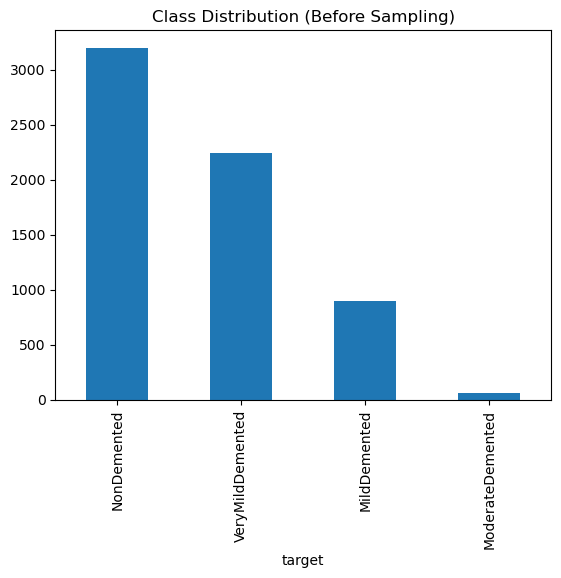

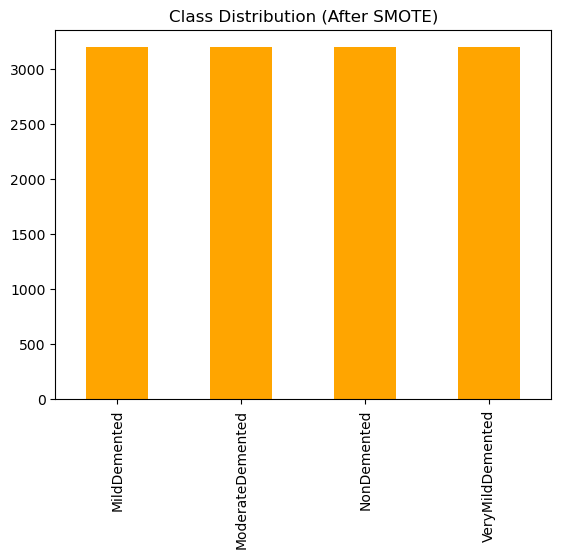

In [25]:
import matplotlib.pyplot as plt

# Before Sampling
df['target'].value_counts().plot(kind='bar', title='Class Distribution (Before Sampling)')
plt.show()

# After SMOTE
y_sm_series.value_counts().plot(kind='bar', title='Class Distribution (After SMOTE)', color='orange')
plt.show()
